# Landmarks and image features

Prepared for Shivam Singh · MathTech

## Theory
Dense anatomical landmarks require the MediaPipe model. Without it, the engine extracts actual image corners and labels them sparse corners. Coordinate normalization divides by image dimensions.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.landmarks.face_landmarks import LandmarkEngine
frame = demo_frame(0)
box = SyntheticDetector().detect(frame)[0].bbox
engine = LandmarkEngine()
landmarks = engine.extract(frame, box)
assert landmarks is not None
print(landmarks.kind, landmarks.points.shape)
print("First normalized points:", landmarks.normalized(800, 480)[:5])


sparse corners (40, 2)
First normalized points: [[0.24375    0.55      ]
 [0.19875    0.55      ]
 [0.2475     0.46458333]
 [0.24       0.46458333]
 [0.20375    0.46458333]]


## Visualization

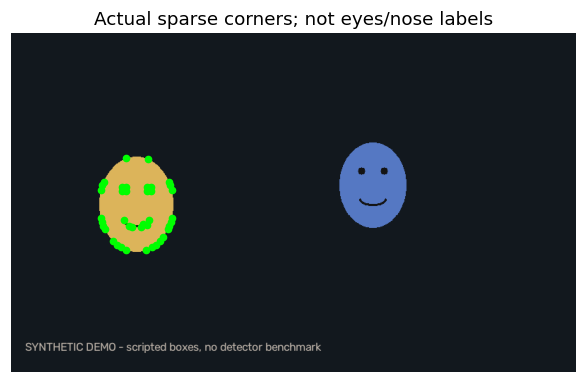

In [3]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.scatter(landmarks.points[:,0], landmarks.points[:,1], c="lime", s=16)
plt.title("Actual sparse corners; not eyes/nose labels"); plt.axis("off"); plt.show()


## Experiment

In [4]:
soft = cv2.GaussianBlur(frame, (25, 25), 6)
soft_points = engine.extract(soft, box)
print("Sharp corner count:", len(landmarks.points))
print("Blurred corner count:", 0 if soft_points is None else len(soft_points.points))
engine.close()


Sharp corner count: 40
Blurred corner count: 38


## Observations
The point detector responds to image texture. To test anatomical features, download face_landmarker.task and initialize LandmarkEngine with its path, then use a real face image. No synthetic anatomical coordinates are presented as inference.

## Conclusion
Do not substitute texture features for a dense facial model in geometric claims.